In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn
from sklearn.metrics import classification_report
from keras.applications import *
from keras.layers import *
from keras.models import Model, load_model
from keras.optimizers import Adam, AdamW
from sklearn.utils import class_weight
from tqdm import tqdm
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.efficientnet_v2 import preprocess_input as base_preprocess
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, auc
from sklearn.utils.multiclass import unique_labels
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import itertools

In [2]:
tf.keras.backend.clear_session()

**Load data**

In [4]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# === 1. Paths ===
base_dir = r"C:\Users\falco\Desktop\emp\BTDataset"
base_dir = os.path.normpath(base_dir)

train_dir = os.path.join(base_dir, "Training")

print("base_dir:", repr(base_dir))
print("train_dir exists:", os.path.exists(train_dir))
print("-" * 40)

# === 2. Data loading and preprocessing ===
images = []
labels = []
bad_reads = 0

# ✅ Only load images from the Training folder
folder_path = train_dir
if not os.path.exists(folder_path):
    print(f"❌ Training folder not found: {folder_path}")
    sys.exit(1)

# Loop through each class folder (glioma, meningioma, etc.)
for class_name in os.listdir(folder_path):
    class_path = os.path.join(folder_path, class_name)
    if not os.path.isdir(class_path):
        continue
    
    # Iterate through all image files inside the class folder
    for fname in os.listdir(class_path):
        if not (fname.lower().endswith(".jpg") or fname.lower().endswith(".png")):
            continue
        
        fpath = os.path.join(class_path, fname)
        img = cv2.imread(fpath)
        if img is None:
            bad_reads += 1
            continue
        
        # Convert BGR to RGB and resize to 224x224
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        
        images.append(img)
        labels.append(class_name)

print("Total images loaded:", len(images))
print("Bad reads:", bad_reads)

if len(images) == 0:
    print("❌ No images found — exiting.")
    sys.exit(1)

# === 3. Convert to NumPy arrays ===
images = np.array(images, dtype=np.uint8)
labels = np.array(labels, dtype=str)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique classes:", np.unique(labels))

# === 4. Label encoding and one-hot conversion ===
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_onehot = to_categorical(labels_encoded)

print("Classes and indices:", list(zip(le.classes_, range(len(le.classes_)))))
print("One-hot labels shape:", labels_onehot.shape)

# === 5. Save .npy files ===
data_path = os.path.join(r"C:\Users\falco\Desktop\emp\Data", "data.npy")
labels_path = os.path.join(r"C:\Users\falco\Desktop\emp\Data", "labels.npy")

try:
    np.save(data_path, images, allow_pickle=False)
    np.save(labels_path, labels_onehot, allow_pickle=False)
except Exception as e:
    print("❌ Error while saving:", e)
    sys.exit(1)

print("✅ Saved successfully:")
print(" -", data_path)
print(" -", labels_path)




base_dir: 'C:\\Users\\falco\\Desktop\\emp\\BTDataset'
train_dir exists: True
----------------------------------------
Total images loaded: 5712
Bad reads: 0
Images shape: (5712, 224, 224, 3)
Labels shape: (5712,)
Unique classes: ['glioma' 'meningioma' 'notumor' 'pituitary']
Classes and indices: [('glioma', 0), ('meningioma', 1), ('notumor', 2), ('pituitary', 3)]
One-hot labels shape: (5712, 4)
✅ Saved successfully:
 - C:\Users\falco\Desktop\emp\Data\data.npy
 - C:\Users\falco\Desktop\emp\Data\labels.npy


In [5]:
base_dir = r"C:\Users\falco\Desktop\emp\Data"
base_dir = os.path.normpath(base_dir)


data_path = os.path.join(base_dir, "data.npy")
labels_path = os.path.join(base_dir, "labels.npy")

# === 6. Verification (load and check shapes) ===
data = np.load(data_path, mmap_mode='r')
labels = np.load(labels_path, mmap_mode='r')

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (5712, 224, 224, 3)
Labels shape: (5712, 4)


Loading Images from the data

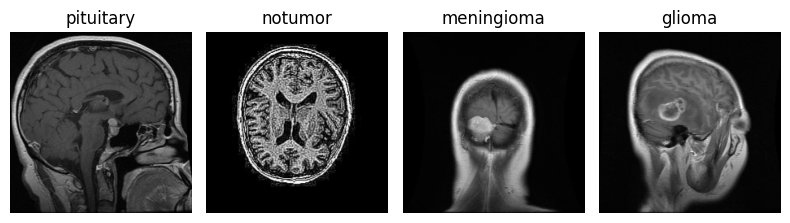

In [6]:
# Get unique one-hot class labels
unique_classes = np.unique(labels, axis=0)

# Create a dictionary to store one image sample per class
class_samples = {}

# Map class indices to their names (from LabelEncoder)
class_names = {0: "glioma", 1: "meningioma", 2: "notumor", 3: "pituitary"}

for class_label in unique_classes:
    class_indices = np.where(np.all(labels == class_label, axis=1))[0]
    random_index = np.random.choice(class_indices)  # 🔹 choose random sample
    class_samples[tuple(class_label)] = data[random_index]

# Plot one example per class
plt.figure(figsize=(8, 4))
for i, (class_label, image_data) in enumerate(class_samples.items()):
    class_index = np.argmax(class_label)   # find class index from one-hot
    class_name = class_names[class_index]  # map to name
    plt.subplot(1, 4, i + 1)
    plt.imshow(image_data)
    plt.title(f'{class_name}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Frequency of the data

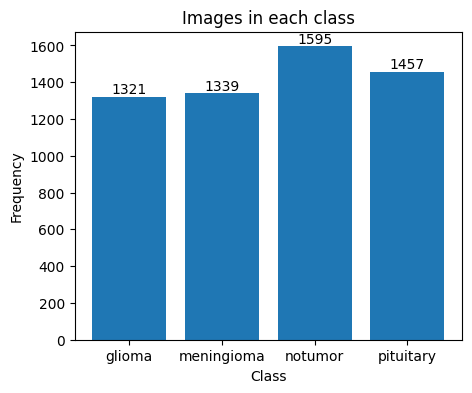

In [7]:
# Sum the one-hot encoded labels along the rows to get the frequency of each class
class_counts = np.sum(labels, axis=0)

# Map class indices to their corresponding names
class_names = {0: "glioma", 1: "meningioma", 2: "notumor", 3: "pituitary"}

# Plot the class frequencies
plt.figure(figsize=(5, 4))
plt.bar([class_names[class_idx] for class_idx in range(len(class_names))], class_counts)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Images in each class')

# Annotate the bars with the class frequencies (integer format)
for i, count in enumerate(class_counts):
    plt.text(i, count, str(int(count)), ha='center', va='bottom')

plt.show()


Split data

In [7]:
# Split the data into train, test, and validation sets
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.1,stratify=labels, random_state=42)
train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size=0.1,stratify=train_labels, random_state=42)

Split Data Frequecy

In [9]:
print("train_data shape:", train_data.shape)
print("train_labels shape:", train_labels.shape)
print("val_data shape:", val_data.shape)
print("val_labels shape:", val_labels.shape)
print("test_data shape:", test_data.shape)
print("test_labels shape:", test_labels.shape)

train_data shape: (4626, 224, 224, 3)
train_labels shape: (4626, 4)
val_data shape: (514, 224, 224, 3)
val_labels shape: (514, 4)
test_data shape: (572, 224, 224, 3)
test_labels shape: (572, 4)


Data Frequency of Each Class

In [10]:
# Class name mapping for MRI dataset
class_names_mapping = {
    0: "glioma",
    1: "meningioma",
    2: "notumor",
    3: "pituitary"
}

# Calculate class distribution in each set
num_classes = train_labels.shape[1]
class_counts_train = np.sum(train_labels, axis=0)
class_counts_val = np.sum(val_labels, axis=0)
class_counts_test = np.sum(test_labels, axis=0)

# Store counts for each class
class_counts_mapping = {}
for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name] = {'Train': class_counts_train[index]}

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Validation'] = class_counts_val[index]

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Test'] = class_counts_test[index]

# Print class distribution mapping
for class_name, counts in class_counts_mapping.items():
    print(class_name)
    for set_name, count in counts.items():
        print(f" - {set_name}: {int(count)}")


glioma
 - Train: 1070
 - Validation: 119
 - Test: 132
meningioma
 - Train: 1085
 - Validation: 120
 - Test: 134
notumor
 - Train: 1291
 - Validation: 144
 - Test: 160
pituitary
 - Train: 1180
 - Validation: 131
 - Test: 146


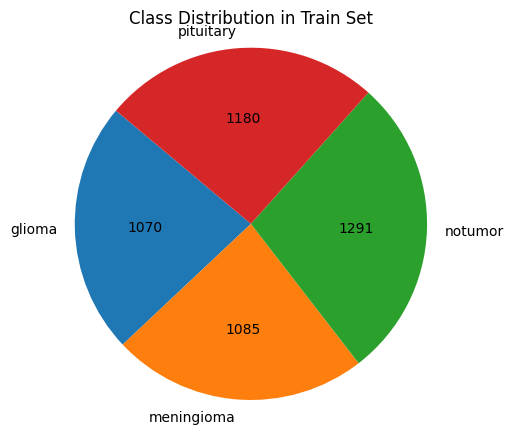

In [11]:
# Create pie charts for each set
for set_name in ['Train']:
    class_counts = [counts[set_name] for counts in class_counts_mapping.values()]
    class_labels = list(class_counts_mapping.keys())

    plt.figure(figsize=(5, 5))
    plt.pie(class_counts, labels=class_labels, startangle=140, autopct=lambda p: '{:.0f}'.format(p * sum(class_counts) / 100))
    plt.title(f'Class Distribution in {set_name} Set')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

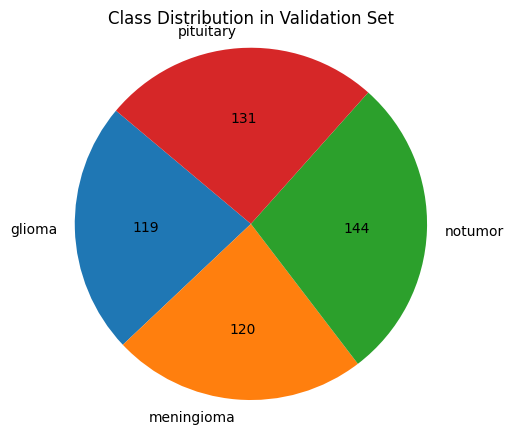

In [12]:
# Create pie charts for each set
for set_name in ['Validation']:
    class_counts = [counts[set_name] for counts in class_counts_mapping.values()]
    class_labels = list(class_counts_mapping.keys())

    plt.figure(figsize=(5, 5))
    plt.pie(class_counts, labels=class_labels, startangle=140, autopct=lambda p: '{:.0f}'.format(p * sum(class_counts) / 100))
    plt.title(f'Class Distribution in {set_name} Set')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

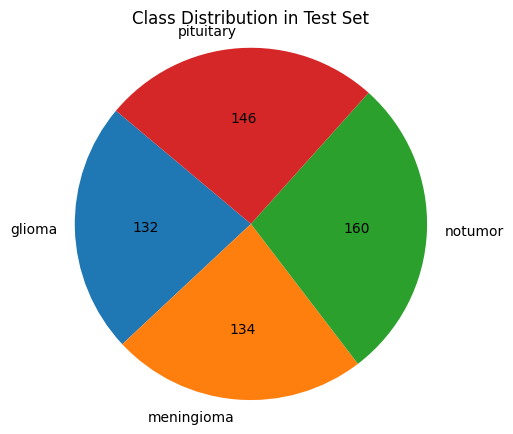

In [13]:
# Create pie charts for each set
for set_name in ['Test']:
    class_counts = [counts[set_name] for counts in class_counts_mapping.values()]
    class_labels = list(class_counts_mapping.keys())

    plt.figure(figsize=(5, 5))
    plt.pie(class_counts, labels=class_labels, startangle=140, autopct=lambda p: '{:.0f}'.format(p * sum(class_counts) / 100))
    plt.title(f'Class Distribution in {set_name} Set')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

Augmentation

In [9]:
datagen = ImageDataGenerator(
    rotation_range=25,          # Increased (was 20) – better rotational robustness
    width_shift_range=0.15,     # Reduced (was 0.2) – avoids excessive horizontal shifting of lesion
    height_shift_range=0.15,    # Reduced (was 0.2) – prevents tumor area misalignment
    shear_range=0.15,           # Softer shear (was 0.2) – less geometric distortion
    zoom_range=0.25,            # Increased (was 0.2) – more variability in lesion scaling
    brightness_range=[0.8, 1.2],# simulates different MRI lighting and scanner exposure
    horizontal_flip=True,       
    fill_mode='nearest',        # preserves edge pixels instead of filling with black
    rescale=1./255              # normalizes pixel values to [0,1], improves convergence
)

val_datagen = ImageDataGenerator(rescale=1./255)

Callbacks

In [10]:

lr_reduce = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,            # was 5 — reacts slightly faster to plateau
    mode='max',
    min_lr=1e-6,           # was 1e-4 — allows finer learning rate reduction
    verbose=1
)

save_dir = r"C:\Users\falco\Desktop\emp\SavedModels"
os.makedirs(save_dir, exist_ok=True)
saved_model = os.path.join(save_dir, "EfficientNetV2S_ECA.h5")

model_chkpt = ModelCheckpoint(saved_model ,save_best_only = True, monitor = 'val_accuracy',verbose = 1)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,           # prevents overfitting, restores best weights
    restore_best_weights=True,
    mode='max',
    verbose=1
)


callback_list = [model_chkpt, lr_reduce, early_stop]


EfficientNetV2S Model

In [11]:
base_model = EfficientNetV2S(weights='imagenet',
                             include_top=False,
                             input_shape=(224, 224, 3))

ECA

In [12]:
def eca_block(x, gamma=2, b=1):
    channels = x.shape[-1]
    t = int(abs((np.log2(channels) + b) / gamma))
    k = t if t % 2 else t + 1
    k = max(3, k) 

    y = tf.reduce_mean(x, axis=[1, 2], keepdims=False)  # (B, C)
    y = tf.expand_dims(y, axis=-1)                      # (B, C, 1)
    y = Conv1D(filters=1, kernel_size=k, padding='same', use_bias=False)(y)
    y = tf.squeeze(y, axis=-1)
    y = tf.nn.sigmoid(y)
    y = tf.reshape(y, (-1, 1, 1, channels))
    return x * y

GAM

In [13]:
def gam_block(x):
    ch = x.shape[-1]
    ch_att = GlobalAveragePooling2D()(x)
    ch_att = Dense(ch // 16, activation='relu')(ch_att)
    ch_att = Dense(ch, activation='sigmoid')(ch_att)
    ch_att = tf.reshape(ch_att, [-1, 1, 1, ch])
    x = Multiply()([x, ch_att])

    spatial_att = Conv2D(ch // 16, 1, activation='relu', padding='same')(x)
    spatial_att = Conv2D(ch, 1, activation='sigmoid', padding='same')(spatial_att)
    x = Multiply()([x, spatial_att])
    return x

In [14]:
x = base_model.output
x = gam_block(x)   
x = eca_block(x)    
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)        # was 128
x = BatchNormalization()(x)                 # helps regularize and stabilize training
x = Dropout(0.3)(x)                         # was 0.4
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


# Compile the model
model.compile(
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-4),  # AdamW instead of plain Adam
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Training

In [15]:
epochs = 50
batch_size = 16

In [16]:
history = model.fit(
    datagen.flow(train_data, train_labels, batch_size=batch_size),
    validation_data=val_datagen.flow(val_data, val_labels, batch_size=batch_size, shuffle=False),
    epochs=epochs,
    callbacks=callback_list
)


Epoch 1/50
290/290 [==============================] - ETA: 0s - loss: 0.4646 - accuracy: 0.8342
Epoch 1: val_accuracy improved from -inf to 0.91051, saving model to C:\Users\falco\Desktop\emp\SavedModels\EfficientNetV2S_ECA.h5


c:\Users\falco\Desktop\emp\.venv_gpu\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


290/290 [==============================] - 1050s 3s/step - loss: 0.4646 - accuracy: 0.8342 - val_loss: 0.6299 - val_accuracy: 0.9105 - lr: 3.0000e-04
Epoch 2/50
290/290 [==============================] - ETA: 0s - loss: 0.2186 - accuracy: 0.9174
Epoch 2: val_accuracy improved from 0.91051 to 0.96498, saving model to C:\Users\falco\Desktop\emp\SavedModels\EfficientNetV2S_ECA.h5
290/290 [==============================] - 965s 3s/step - loss: 0.2186 - accuracy: 0.9174 - val_loss: 0.1254 - val_accuracy: 0.9650 - lr: 3.0000e-04
Epoch 3/50
290/290 [==============================] - ETA: 0s - loss: 0.1845 - accuracy: 0.9408
Epoch 3: val_accuracy did not improve from 0.96498
290/290 [==============================] - 964s 3s/step - loss: 0.1845 - accuracy: 0.9408 - val_loss: 0.1137 - val_accuracy: 0.9650 - lr: 3.0000e-04
Epoch 4/50
290/290 [==============================] - ETA: 0s - loss: 0.1296 - accuracy: 0.9604
Epoch 4: val_accuracy did not improve from 0.96498
290/290 [===================

In [17]:
model = load_model(r"C:\Users\falco\Desktop\emp\SavedModels\EfficientNetV2S_ECA.h5")

Test Accuracy

In [18]:
test_loss, test_accuracy = model.evaluate(test_data / 255.0, test_labels)
print("Test Accuracy:", test_accuracy)

18/18 [==============================] - 25s 1s/step - loss: 0.0442 - accuracy: 0.9808
Test Accuracy: 0.9807692170143127


Classification Report

In [19]:
# Make predictions on the test data
predictions = model.predict(test_data / 255.0)

# Convert predictions and true labels to integer format
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Calculate the classification report
report = classification_report(true_labels, predicted_labels)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Print the classification report
print("Classification Report:")
print(report)


18/18 [==============================] - 29s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       132
           1       0.96      0.96      0.96       134
           2       0.98      1.00      0.99       160
           3       0.98      0.99      0.99       146

    accuracy                           0.98       572
   macro avg       0.98      0.98      0.98       572
weighted avg       0.98      0.98      0.98       572



Confusion Matrix

In [20]:
# Calculate the confusion matrix
cm = confusion_matrix(true_labels, np.round(predicted_labels))

cm

array([[128,   4,   0,   0],
       [  0, 128,   3,   3],
       [  0,   0, 160,   0],
       [  0,   1,   0, 145]], dtype=int64)

Normalized confusion matrix


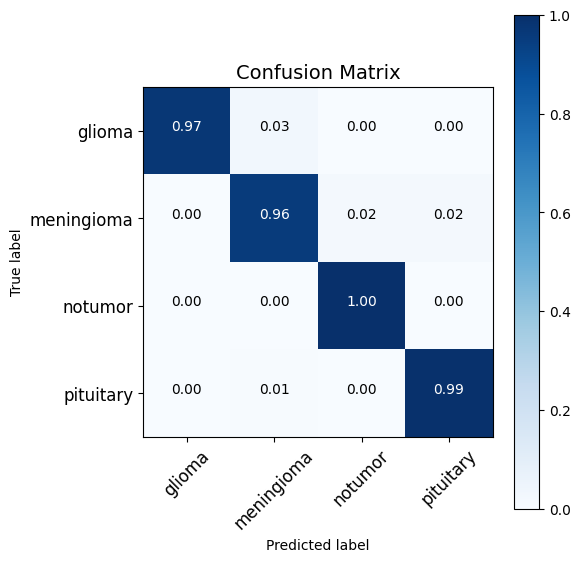

In [21]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    # print(cm)

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels = ["glioma", "meningioma", "notumor", "pituitary"]

plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)

ROC-AUC curve

18/18 [==============================] - 24s 1s/step


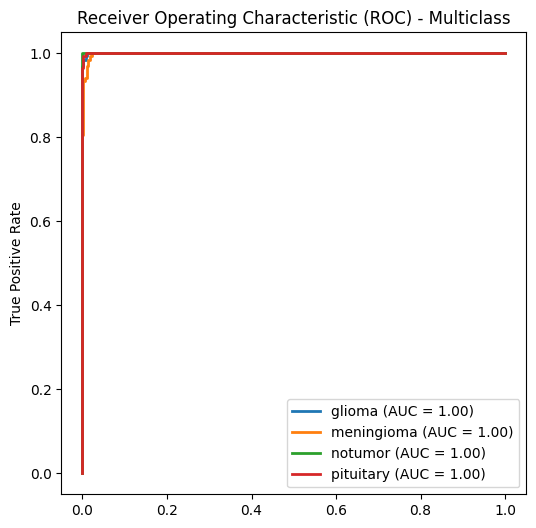

In [22]:
# Define class names
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Make predictions on the test data
predictions = model.predict(test_data / 255.0)

# Get the number of classes
num_classes = test_labels.shape[1]

# Initialize a figure to plot ROC curves
plt.figure(figsize=(6, 6))

# Loop through each class
for class_index in range(num_classes):
    # Compute ROC curve and ROC AUC for the current class
    fpr, tpr, thresholds = roc_curve(test_labels[:, class_index], predictions[:, class_index])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for the current class
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[class_index]} (AUC = {roc_auc:.2f})')
# Plot the diagonal line (random chance)plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)# Set plot propertiesplt.xlim([0.0, 1.0])plt.ylim([0.0, 1.05])plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc='lower right')

# Display the plot
plt.show()

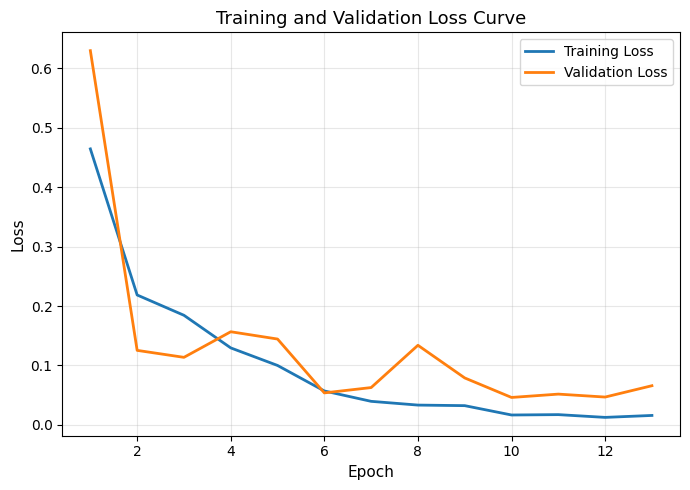

In [23]:
# Extract loss history
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss Curve', fontsize=13)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Explainable AI (XAI)

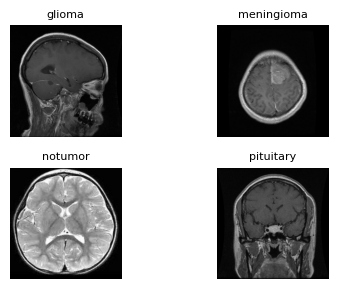

In [24]:
image_titles = ["glioma", "meningioma", "notumor", "pituitary"]
num_images = len(image_titles)

# Convert one-hot encoded labels to integer labels
test_labels_int = np.argmax(test_labels, axis=1)
# Find the indices of the first image from each class
class_indices = [np.where(test_labels_int == i)[0][0] for i in range(len(image_titles))]

# Create an array to store the images
image_array = []

# Create subplots with 2 rows
num_rows = 2
num_cols = (num_images + 1) // num_rows
fig, ax = plt.subplots(num_rows, num_cols, figsize=(5, 3))

for i, title in enumerate(image_titles):
    row = i // num_cols
    col = i % num_cols
    ax[row, col].set_title(title, fontsize=8)

    # Display the image from test data
    img = test_data[class_indices[i]]
    image_array.append(img)  # Store the image in the array

    ax[row, col].imshow(img)
    ax[row, col].axis('off')

# Remove any empty subplots
for i in range(len(image_titles), num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    fig.delaxes(ax[row, col])

plt.tight_layout()
plt.show()

X = base_preprocess(np.array(image_array))

Random Image

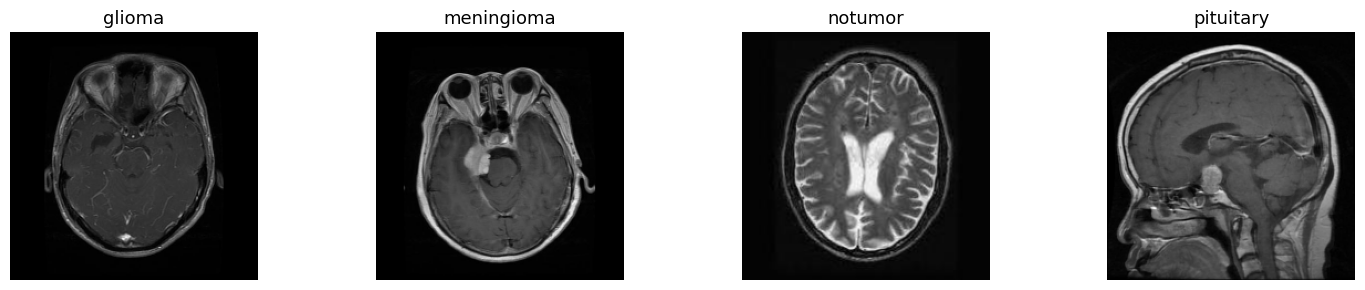

In [25]:
import random

image_titles = ["glioma", "meningioma", "notumor", "pituitary"]
num_images = len(image_titles)

test_labels_int = np.argmax(test_labels, axis=1)

class_indices = [random.choice(np.where(test_labels_int == i)[0]) for i in range(len(image_titles))]

image_array = []

fig, ax = plt.subplots(1, num_images, figsize=(15, 3))
for i, title in enumerate(image_titles):
    ax[i].set_title(title, fontsize=13)
    ax[i].axis('off')

    img = test_data[class_indices[i]]
    image_array.append(img)
    ax[i].imshow(img)

plt.tight_layout()
plt.show()

X = base_preprocess(np.array(image_array))


In [26]:
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

replace2linear = ReplaceToLinear()

def model_modifier_function(cloned_model):
    cloned_model.layers[-1].activation = tf.keras.activations.linear

In [27]:
from tf_keras_vis.utils.scores import CategoricalScore

score = CategoricalScore([0, 1, 2, 3])


def score_function(output):

    return (output[0][1][2][3])


X_vis = X / 255.0



In [29]:
for layer in model.layers[::-1]:
    if 'conv' in layer.name:
        print(layer.name)
        break


conv1d


Faster Score-Cam

4/4 [==============================] - 7s 1s/step


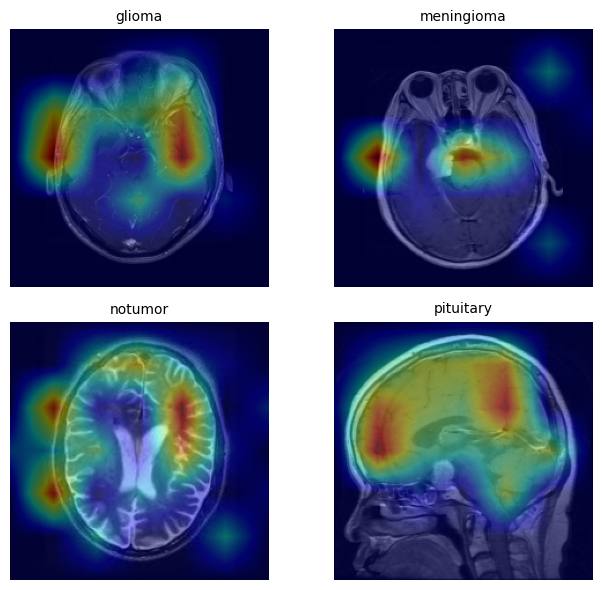

CPU times: total: 47.5 s
Wall time: 13.4 s


In [31]:
%%time
from matplotlib import cm
from tf_keras_vis.scorecam import Scorecam

scorecam = Scorecam(model, model_modifier=replace2linear)
penultimate_layer = 'top_conv'
cam = scorecam(
    score,
    X_vis,
    penultimate_layer=penultimate_layer,   
    max_N=10
)

# Normalize CAMs for visualization (0–1 range)
cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))


num_images = len(image_titles)
num_rows, num_cols = 2, 2  # since you have 4 classes

fig, ax = plt.subplots(num_rows, num_cols, figsize=(7, 6))

for i, title in enumerate(image_titles):
    r, c = divmod(i, num_cols)

    base_img = X_vis[i]

    heatmap = cm.jet(cam[i])[..., :3]

    blended = 0.6 * base_img + 0.4 * heatmap

    ax[r, c].imshow(np.clip(blended, 0, 1))
    ax[r, c].set_title(title, fontsize=10)
    ax[r, c].axis('off')

for i in range(num_images, num_rows * num_cols):
    r, c = divmod(i, num_cols)
    fig.delaxes(ax[r, c])

plt.tight_layout()
plt.show()

In [32]:
%%time
from matplotlib import pyplot as plt, cm
from tf_keras_vis.scorecam import Scorecam

scorecam = Scorecam(model, model_modifier=replace2linear)
cam = scorecam(score, X / 255.0, penultimate_layer=-1, max_N=10)
cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))

num_images = len(image_titles)
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i, title in enumerate(image_titles):
    heatmap = cm.jet(cam[i])[..., :3]
    base_img = X[i] / 255.0
    blended = 0.6 * base_img + 0.4 * heatmap
    axes[i].set_title(title, fontsize=13)
    axes[i].imshow(np.clip(blended, 0, 1))
    axes[i].axis('off')

plt.tight_layout()
plt.show()

CPU times: total: 7.78 s
Wall time: 4.47 s


ValueError: max_N must be 1 or more and 1 or less. max_N: 10